# BuySense - Decision Tree Modelling
## Member 3

This notebook contains the Decision Tree experiments for the BuySense
online purchase prediction problem.

### Responsibilities
- Decision Tree baseline
- Class-weighted Decision Tree
- Decision Tree hyperparameter tuning
- Overfitting analysis
- Feature importance
- Leakage-safe feature selection
- Comparison of baseline and tuned configurations

The experiments use the shared 80/20 stratified train-test split,
5-fold StratifiedKFold cross-validation, the shared preprocessing
pipeline, and the agreed evaluation metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    make_scorer
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/online_shoppers_intention.csv")

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (12330, 18)


In [4]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget proportions:")
print(y.value_counts(normalize=True))

X shape: (12330, 17)
y shape: (12330,)

Target distribution:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Target proportions:
Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train purchase rate:", y_train.mean())
print("Test purchase rate:", y_test.mean())

Train shape: (9864, 17)
Test shape: (2466, 17)
Train purchase rate: 0.15470397404703973
Test purchase rate: 0.1549067315490673


In [6]:
def add_engineered_features(data):
    data = data.copy()

    data["TotalPages"] = (
        data["Administrative"]
        + data["Informational"]
        + data["ProductRelated"]
    )

    data["TotalDuration"] = (
        data["Administrative_Duration"]
        + data["Informational_Duration"]
        + data["ProductRelated_Duration"]
    )

    data["AvgDurationPerPage"] = np.where(
        data["TotalPages"] > 0,
        data["TotalDuration"] / data["TotalPages"],
        0
    )

    data["ProductPageShare"] = np.where(
        data["TotalPages"] > 0,
        data["ProductRelated"] / data["TotalPages"],
        0
    )

    data["ProductDurationShare"] = np.where(
        data["TotalDuration"] > 0,
        data["ProductRelated_Duration"] / data["TotalDuration"],
        0
    )

    return data

X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

engineered_features = [
    "TotalPages",
    "TotalDuration",
    "AvgDurationPerPage",
    "ProductPageShare",
    "ProductDurationShare"
]

print(X_train[engineered_features].isna().sum())
print(np.isinf(X_train[engineered_features]).sum())

TotalPages              0
TotalDuration           0
AvgDurationPerPage      0
ProductPageShare        0
ProductDurationShare    0
dtype: int64
TotalPages              0
TotalDuration           0
AvgDurationPerPage      0
ProductPageShare        0
ProductDurationShare    0
dtype: int64


In [7]:
categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

boolean_features = [
    "Weekend"
]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features + boolean_features
]

In [8]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        ("bool", "passthrough", boolean_features)
    ]
)

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [10]:
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [11]:
def summarize_cv(model_name, pipeline, X_data, y_data):

    scores = cross_validate(
        pipeline,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    row = {"Model": model_name}

    for metric in scoring:
        row[f"CV_{metric}_mean"] = scores[
            f"test_{metric}"
        ].mean()

        row[f"CV_{metric}_std"] = scores[
            f"test_{metric}"
        ].std()

    row["Train_F1_mean"] = scores["train_f1"].mean()
    row["Validation_F1_mean"] = scores["test_f1"].mean()

    return row, scores

## 1. Decision Tree Baseline

In [12]:
dt_baseline = Pipeline([
    ("preprocessor", preprocessor_tree),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

In [13]:
dt_baseline_row, dt_baseline_scores = summarize_cv(
    "Decision Tree - Baseline",
    dt_baseline,
    X_train,
    y_train
)

In [14]:
pd.DataFrame([dt_baseline_row])

,Model,CV_accuracy_mean,CV_accuracy_std,CV_precision_mean,CV_precision_std,CV_recall_mean,CV_recall_std,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,CV_pr_auc_mean,CV_pr_auc_std,Train_F1_mean,Validation_F1_mean
0,Decision Tree - Baseline,0.865471,0.007685,0.563289,0.02517,0.585835,0.013664,0.574213,0.018844,0.751242,0.009688,0.394341,0.019307,1.0,0.574213


## 2. Class-Weighted Decision Tree

In [ ]:
dt_balanced = Pipeline([
    ("preprocessor", preprocessor_tree),
    (
        "model",
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        )
    )
])

In [16]:
dt_balanced_row, dt_balanced_scores = summarize_cv(
    "Decision Tree - Balanced",
    dt_balanced,
    X_train,
    y_train
)

In [17]:
dt_balance_comparison = pd.DataFrame([
    dt_baseline_row,
    dt_balanced_row
])

dt_balance_comparison[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean",
        "Train_F1_mean",
        "Validation_F1_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean,Train_F1_mean,Validation_F1_mean
0,Decision Tree - Baseline,0.865471,0.563289,0.585835,0.574213,0.751242,0.394341,1.0,0.574213
1,Decision Tree - Balanced,0.862632,0.556300,0.558980,0.557377,0.738593,0.379187,1.0,0.557377


## 3. Decision Tree Hyperparameter Tuning

In [18]:
dt_tune_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

In [19]:
dt_param_grid = {
    "model__criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "model__max_depth": [
        None,
        3,
        5,
        8,
        12,
        16
    ],

    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "model__min_samples_leaf": [
        1,
        2,
        5,
        10
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}

In [20]:
dt_search = GridSearchCV(
    estimator=dt_tune_pipeline,
    param_grid=dt_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

In [21]:
dt_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__class_weight': [None, 'balanced'], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [None, 3, ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [22]:
print("Best CV PR-AUC:", dt_search.best_score_)
print("Best parameters:", dt_search.best_params_)

Best CV PR-AUC: 0.7016401372788479
Best parameters: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}


In [23]:
best_dt = dt_search.best_estimator_

## 4. Baseline vs Tuned Decision Tree

In [24]:
dt_tuned_row, dt_tuned_scores = summarize_cv(
    "Decision Tree - Tuned",
    best_dt,
    X_train,
    y_train
)

In [25]:
dt_comparison = pd.DataFrame([
    dt_baseline_row,
    dt_balanced_row,
    dt_tuned_row
])

In [26]:
dt_comparison[
    [
        "Model",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean",
        "Train_F1_mean",
        "Validation_F1_mean"
    ]
]

,Model,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean,Train_F1_mean,Validation_F1_mean
0,Decision Tree - Baseline,0.563289,0.585835,0.574213,0.751242,0.394341,1.000000,0.574213
1,Decision Tree - Balanced,0.556300,0.558980,0.557377,0.738593,0.379187,1.000000,0.557377
2,Decision Tree - Tuned,0.498096,0.863019,0.631248,0.923744,0.701640,0.646914,0.631248


### Overfitting Analysis

The baseline Decision Tree achieved a training F1-score of 1.000000 and
validation F1-score of 0.574213.

The difference between training and validation performance is large, indicating significant overfitting.

After tuning, the training F1-score was 0.646914 while the validation
F1-score was 0.631248.

This indicates that the tuning process reduced overfitting and improved the model's ability to generalize to unseen data.

## 5. Decision Tree Feature Importance

In [27]:
best_dt.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
dt_preprocessor = best_dt.named_steps["preprocessor"]
dt_model = best_dt.named_steps["model"]

In [29]:
dt_feature_names = dt_preprocessor.get_feature_names_out()

In [30]:
dt_importance = pd.DataFrame({
    "Feature": dt_feature_names,
    "Importance": dt_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

In [31]:
dt_importance.head(20)

,Feature,Importance
8,num__PageValues,0.727846
22,cat__Month_Nov,0.088509
21,cat__Month_May,0.038175
20,cat__Month_Mar,0.035037
13,num__ProductPageShare,0.026832
6,num__BounceRates,0.024480
5,num__ProductRelated_Duration,0.018847
10,num__TotalPages,0.016533
0,num__Administrative,0.004701
7,num__ExitRates,0.003822


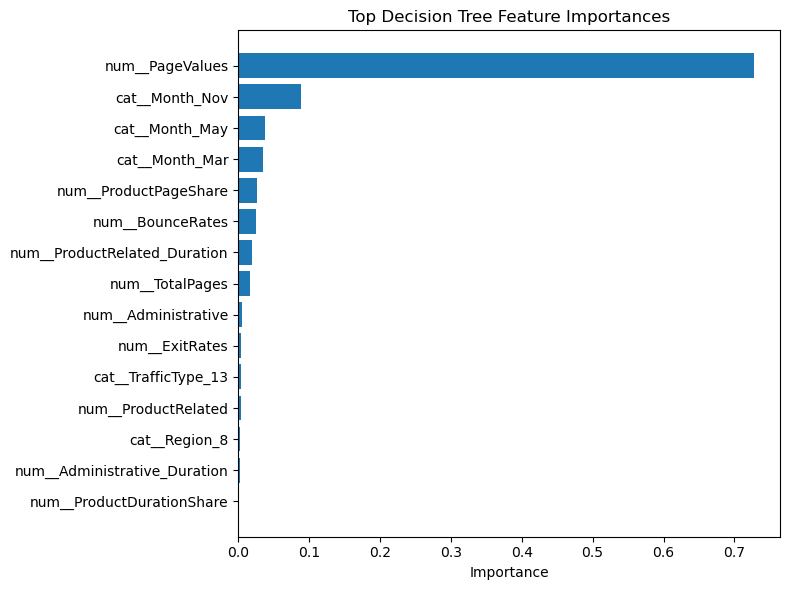

In [32]:
top_dt = (
    dt_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_dt["Feature"],
    top_dt["Importance"]
)

plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 6. Leakage-Safe Feature Selection

In [33]:
selection_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor_tree
    ),

    (
        "selector",
        SelectFromModel(
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ),
            threshold="median"
        )
    ),

    (
        "model",
        DecisionTreeClassifier(
            **{
                key.replace("model__", ""): value
                for key, value in dt_search.best_params_.items()
            },
            random_state=42
        )
    )
])

In [34]:
selection_row, selection_scores = summarize_cv(
    "Decision Tree - Tuned + Feature Selection",
    selection_pipeline,
    X_train,
    y_train
)

In [ ]:
selection_pipeline.fit(X_train, y_train)

selector = selection_pipeline.named_steps["selector"]

selected_mask = selector.get_support()

print("Original transformed feature count:", len(selected_mask))
print("Selected feature count:", selected_mask.sum())

selected_features = np.array(
    selection_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)[selected_mask]

print("Selected features:")
print(selected_features)

Original transformed feature count: 79
Selected feature count: 40
Selected features:
['num__Administrative' 'num__Administrative_Duration' 'num__Informational'
 'num__Informational_Duration' 'num__ProductRelated'
 'num__ProductRelated_Duration' 'num__BounceRates' 'num__ExitRates'
 'num__PageValues' 'num__TotalPages' 'num__TotalDuration'
 'num__AvgDurationPerPage' 'num__ProductPageShare'
 'num__ProductDurationShare' 'cat__Month_Dec' 'cat__Month_Mar'
 'cat__Month_May' 'cat__Month_Nov' 'cat__Month_Oct' 'cat__Month_Sep'
 'cat__OperatingSystems_1' 'cat__OperatingSystems_2'
 'cat__OperatingSystems_3' 'cat__Browser_1' 'cat__Browser_2'
 'cat__Browser_4' 'cat__Region_1' 'cat__Region_2' 'cat__Region_3'
 'cat__Region_4' 'cat__Region_6' 'cat__TrafficType_1' 'cat__TrafficType_2'
 'cat__TrafficType_3' 'cat__TrafficType_4' 'cat__TrafficType_8'
 'cat__TrafficType_10' 'cat__VisitorType_New_Visitor'
 'cat__VisitorType_Returning_Visitor' 'bool__Weekend']


In [36]:
pd.DataFrame([
    dt_tuned_row,
    selection_row
])[
    [
        "Model",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean"
    ]
]

,Model,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean
0,Decision Tree - Tuned,0.631248,0.923744,0.701640
1,Decision Tree - Tuned + Feature Selection,0.631248,0.923399,0.701535


In [37]:
member3_results = pd.DataFrame([
    dt_baseline_row,
    dt_balanced_row,
    dt_tuned_row,
    selection_row
])

member3_results[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean",
        "Train_F1_mean",
        "Validation_F1_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean,Train_F1_mean,Validation_F1_mean
0,Decision Tree - Baseline,0.865471,0.563289,0.585835,0.574213,0.751242,0.394341,1.000000,0.574213
1,Decision Tree - Balanced,0.862632,0.556300,0.558980,0.557377,0.738593,0.379187,1.000000,0.557377
2,Decision Tree - Tuned,0.843878,0.498096,0.863019,0.631248,0.923744,0.701640,0.646914,0.631248
3,Decision Tree - Tuned + Feature Selection,0.843878,0.498096,0.863019,0.631248,0.923399,0.701535,0.646914,0.631248


## Member 3 Summary

The Decision Tree experiments included:

1. Baseline Decision Tree
2. Class-weighted Decision Tree
3. Hyperparameter-tuned Decision Tree
4. Overfitting analysis using training and validation F1
5. Decision Tree feature importance
6. Leakage-safe feature selection

The experiments were evaluated using 5-fold StratifiedKFold cross-validation
and the shared metrics: accuracy, precision, recall, F1, ROC-AUC and PR-AUC.

The final Decision Tree configuration should be selected based on the
cross-validation evidence, considering minority-class performance,
stability, overfitting and model complexity rather than accuracy alone.